# SIGWAY interface — demo & correctness checks

This notebook shows how the SIGWAY-backed templates work, plots every pre-built
spectrum, and runs two self-contained correctness checks.

**Requirements.** SIGWAY must be installed (`pip install gwb_templates[sigway]`)
in an environment with **JAX ≥ 0.8** (SIGWAY's EMD kernel needs
`jax.scipy.special.sici`). If SIGWAY is missing, the second cell stops with a
clear message.

Contents:
1. Setup & the SIGWAY registry
2. The **general interface** — `sigway_template(...)` with your own `P_ζ(k)`
3. **Gallery** — all five pre-built spectra
4. **Correctness A** — each template reproduces a hand-composed SIGWAY `OmegaGW`
5. **Correctness B** — analytic Jacobian vs finite differences
6. Notes: EMD normalisation & the non-jittable USR path


In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import gwb_templates
from gwb_templates import SIGWAY_AVAILABLE, get_template_from_registry
from gwb_templates.template import Template

## 1. Setup & the SIGWAY registry

In [2]:
if not SIGWAY_AVAILABLE:
    raise RuntimeError(
        "SIGWAY is not importable in this environment.\n"
        "Install it with `pip install gwb_templates[sigway]` and make sure "
        "JAX >= 0.8 is available (SIGWAY's EMD kernel needs jax.scipy.special.sici)."
    )

sigway_templates = sorted(
    n for n in Template.registered_templates() if n.startswith("SIGWAY")
)
print(f"{len(sigway_templates)} SIGWAY templates registered:")
for n in sigway_templates:
    print("  ", n)

5 SIGWAY templates registered:
   SIGWAYBrokenPowerLaw
   SIGWAYEarlyMatterDomination
   SIGWAYLognormal
   SIGWAYMultifieldOscillations
   SIGWAYSingleFieldUSR


## 2. The general interface

`SIGWAYTemplate` wraps a fully-composed `sigway.OmegaGW` (any perturbation
source + any kernel + any integrator/grids). The `sigway_template(...)` factory
turns that composition into a first-class `Template`. Below: supply an arbitrary
closed-form `P_ζ(k)` and get a working template back — no subclassing needed.

parameter_names: ('logAs', 'logks')


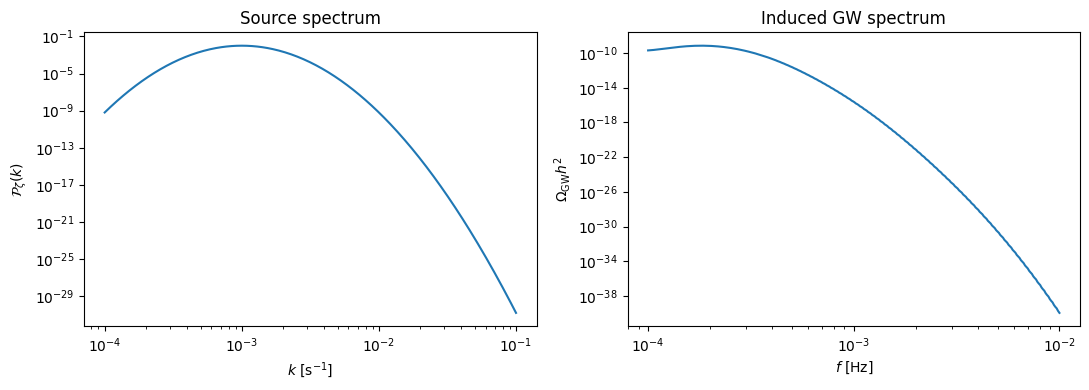

In [3]:
from gwb_templates import sigway_template
from sigway.kernels import RadiationKernel

# A custom source: a log-normal peak in P_zeta(k), parameters (logAs, logks).
def my_pzeta(k, logAs, logks):
    width = 0.4
    return 10.0**logAs * jnp.exp(-0.5 * (jnp.log(k / 10.0**logks) / width) ** 2)

# Standard SIGWAY grids: integrand peaks at t~1 -> linear below 1, geometric above.
s_grid = jnp.linspace(0.0, 1.0, 10)
t_grid = jnp.concatenate([jnp.linspace(1e-5, 0.999, 200), jnp.geomspace(1.0, 1e3, 600)])
f_grid = jnp.geomspace(1e-5, 1e-1, 200)

MyTemplate = sigway_template(
    "DemoCustomLN",
    pzeta=my_pzeta,
    parameter_names=("logAs", "logks"),
    kernel=RadiationKernel(),          # "RD" norm => output is Omega_GW h^2
    s=s_grid, t=t_grid, f=f_grid, upsample=True,
    register=False,                    # throwaway: don't pollute the registry
)

model = MyTemplate()
print("parameter_names:", model.parameter_names)

f = jnp.geomspace(1e-4, 1e-2, 300)
params = {"logAs": -2.0, "logks": -3.0}
omega = model.omega_gw_h2_from_parameters(f, params)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
kk = jnp.geomspace(1e-4, 1e-1, 400)
axL.loglog(kk, my_pzeta(kk, params["logAs"], params["logks"]))
axL.set(xlabel="$k$ [s$^{-1}$]", ylabel=r"$\mathcal{P}_\zeta(k)$", title="Source spectrum")
axR.loglog(f, omega)
axR.set(xlabel="$f$ [Hz]", ylabel=r"$\Omega_{\rm GW}h^2$", title="Induced GW spectrum")
fig.tight_layout()

## 3. Gallery — the five pre-built spectra

Fiducial parameters are those of the configurations tested in
[arXiv:2501.11320](https://arxiv.org/abs/2501.11320).

USR (Mukhanov-Sasaki) is the slow one — it solves the background + mode ODEs.


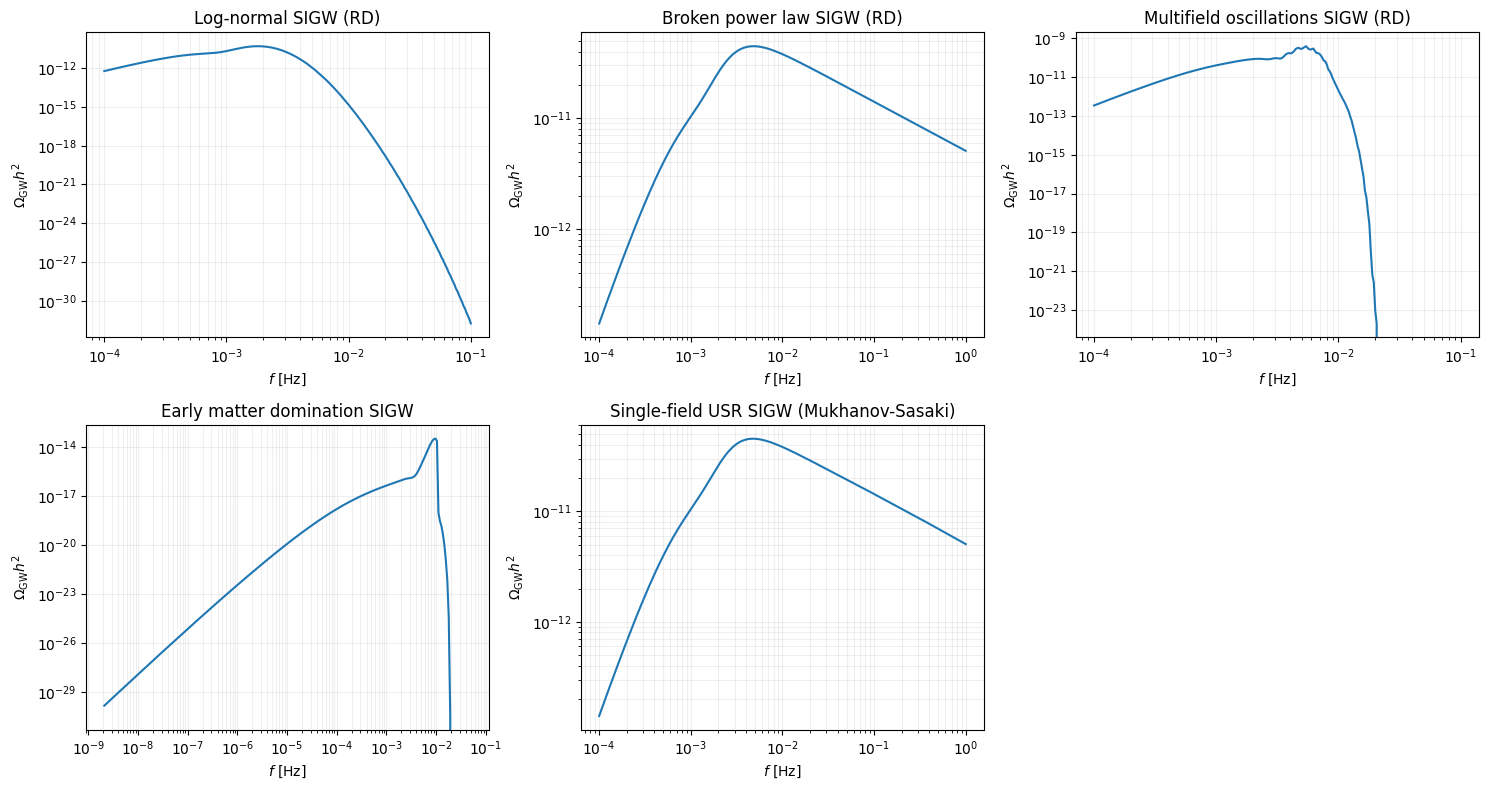

In [4]:
# (template name, fiducial params in parameter_names order, plot frequency range)
FIDUCIALS = {
    "SIGWAYLognormal":             ((-2.5, -0.30102999, -2.0),                                   (1e-4, 1e-1)),
    "SIGWAYBrokenPowerLaw":        ((-2.71028683, 3.10673309, 0.22154827, 1.25417717, -1.58150632), (1e-4, 1e0)),
    "SIGWAYMultifieldOscillations":((-1.5, -1.5, 0.5, 14.0, 1.0),                                 (1e-4, 1e-1)),
    "SIGWAYEarlyMatterDomination": ((2.1e-9, 0.06, 2000.0),                                       (2.1e-9, 5e-2)),
    "SIGWAYSingleFieldUSR":        ((0.7122360088466501, 1.47312e-06, 0.19688844475447168, 1.8690166574800342e-05), (1e-4, 1e0)),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, (name, (p, (flo, fhi))) in zip(axes, FIDUCIALS.items()):
    m = get_template_from_registry(name)
    ff = jnp.geomspace(flo, fhi, 250)
    pmap = dict(zip(m.parameter_names, p))
    om = m.omega_gw_h2_from_parameters(ff, pmap)
    ax.loglog(ff, jnp.abs(om))
    ax.set(xlabel="$f$ [Hz]", ylabel=r"$\Omega_{\rm GW}h^2$", title=m.model_label)
    ax.grid(True, which="both", alpha=0.2)
axes[-1].set_visible(True)
for ax in axes[len(FIDUCIALS):]:
    ax.set_visible(False)
fig.tight_layout()
print("USR (Mukhanov-Sasaki) is the slow one — it solves the background + mode ODEs.")

## 4. Correctness A — wrapper reproduces a hand-composed SIGWAY model

For each pre-built template we rebuild the *equivalent* `sigway.OmegaGW` by hand
(same `P_ζ`, kernel and grids that the template uses) and confirm the wrapped
output is identical. This checks the wiring: parameter order, kernel choice,
normalisation, and the upsample path.

In [5]:
from sigway.spectrum import OmegaGW
from sigway.perturbations import AnalyticPerturbations, SingleFieldPerturbations
from sigway.kernels import RadiationKernel, InstantEMDKernel
from sigway.ms_solver import SingleFieldSolver

from gwb_templates.sigway_templates import (
    lognormal, broken_power_law, multifield_oscillations,
    early_matter_domination, single_field_usr,
)

def reference_model(m):
    # Rebuild the bare SIGWAY OmegaGW matching template instance `m`.
    cls = type(m).__name__
    if cls == "SIGWAYLognormal":
        pert = AnalyticPerturbations(lognormal.pzeta_lognormal, m.parameter_names)
        kern = RadiationKernel()
    elif cls == "SIGWAYBrokenPowerLaw":
        pert = AnalyticPerturbations(broken_power_law.pzeta_broken_power_law, m.parameter_names)
        kern = RadiationKernel()
    elif cls == "SIGWAYMultifieldOscillations":
        pert = AnalyticPerturbations(multifield_oscillations.pzeta_multifield_oscillations, m.parameter_names)
        kern = RadiationKernel()
    elif cls == "SIGWAYEarlyMatterDomination":
        pert = AnalyticPerturbations(
            early_matter_domination.pzeta_flat_cutoff, ("As", "kmax"),
            nonsmooth_params=("kmax",),
        )
        kern = InstantEMDKernel(norm=m._norm)
    else:
        raise NotImplementedError(cls)
    return OmegaGW(pert, kern, s=m._s, t=m._t, f=m._f, upsample=True)

print(f"{'template':32s} {'max rel diff':>14s}")
for name, (p, (flo, fhi)) in FIDUCIALS.items():
    if name == "SIGWAYSingleFieldUSR":
        continue  # MS solver: covered by the gallery run; not a closed-form wiring check
    m = get_template_from_registry(name)
    ref = reference_model(m)
    ff = jnp.geomspace(flo, fhi, 60)
    ours = m.omega_gw_h2_from_parameters(ff, dict(zip(m.parameter_names, p)))
    theirs = ref(ff, *p)
    rel = float(jnp.max(jnp.abs(ours - theirs) / (jnp.abs(theirs) + 1e-300)))
    flag = "OK" if rel < 1e-10 else "*** MISMATCH ***"
    print(f"{name:32s} {rel:14.2e}  {flag}")

template                           max rel diff
SIGWAYLognormal                        0.00e+00  OK
SIGWAYBrokenPowerLaw                   0.00e+00  OK
SIGWAYMultifieldOscillations           0.00e+00  OK
SIGWAYEarlyMatterDomination            0.00e+00  OK


## 5. Correctness B — analytic Jacobian vs finite differences

`grad_theta_omega_gw_h2` uses SIGWAY's `OmegaGW.jacobian` (forward-mode autodiff,
with finite differences for non-smooth parameters such as the EMD cutoff
`kmax`). Here we cross-check it against a plain central finite difference of the
spectrum — a fully independent computation.

In [6]:
def central_fd_jacobian(m, f, p, h_rel=1e-4):
    base = np.asarray(p, dtype=float)
    cols = []
    for i in range(base.size):
        h = h_rel * max(abs(base[i]), 1.0)
        hp, hm = base.copy(), base.copy()
        hp[i] += h; hm[i] -= h
        op = m.omega_gw_h2_from_parameters(f, dict(zip(m.parameter_names, hp)))
        om = m.omega_gw_h2_from_parameters(f, dict(zip(m.parameter_names, hm)))
        cols.append(np.asarray((op - om) / (2 * h)))
    return np.stack(cols, axis=-1)

print(f"{'template':32s} {'max rel diff (analytic vs FD)':>32s}")
for name, (p, (flo, fhi)) in FIDUCIALS.items():
    if name == "SIGWAYSingleFieldUSR":
        continue  # non-jittable FD path; each eval re-solves the ODEs (slow)
    m = get_template_from_registry(name)
    ff = jnp.geomspace(flo * 2, fhi / 2, 25)
    Jana = np.asarray(m.grad_theta_omega_gw_h2(ff, dict(zip(m.parameter_names, p))))
    Jfd = central_fd_jacobian(m, ff, p)
    scale = np.abs(Jfd).max() + 1e-300
    rel = float(np.max(np.abs(Jana - Jfd)) / scale)
    flag = "OK" if rel < 1e-2 else "*** CHECK ***"
    print(f"{name:32s} {rel:32.2e}  {flag}")

template                            max rel diff (analytic vs FD)
SIGWAYLognormal                                          4.86e-07  OK
SIGWAYBrokenPowerLaw                                     2.60e-07  OK
SIGWAYMultifieldOscillations                             4.40e-03  OK
SIGWAYEarlyMatterDomination                              3.77e-10  OK


## 6. Notes

**EMD normalisation.** `SIGWAYEarlyMatterDomination` defaults to `norm="RD"` so
its output is $\Omega_{\rm GW}h^2$ (consistent with every other template). The
paper figures use the dimensionless `"CT"` convention — pass `norm="CT"` to
reproduce them. The two differ by a constant factor $c_g\,\Omega_{r,0}h^2$.

**USR is non-jittable.** The Mukhanov-Sasaki source calls SciPy ODE routines, so
`SIGWAYSingleFieldUSR` advertises `jittable=False` and uses finite-difference
derivatives automatically.

In [7]:
emd = get_template_from_registry("SIGWAYEarlyMatterDomination")
emd_ct = type(emd)(norm="CT")
ff = jnp.geomspace(1e-6, 1e-2, 120)
p = FIDUCIALS["SIGWAYEarlyMatterDomination"][0]
o_rd = emd.omega_gw_h2_from_parameters(ff, dict(zip(emd.parameter_names, p)))
o_ct = emd_ct.omega_gw_h2_from_parameters(ff, dict(zip(emd_ct.parameter_names, p)))
ratio = float(jnp.nanmedian(o_rd / o_ct))
print(f"RD/CT ratio (≈ c_g * Omega_r0 h^2): {ratio:.3e}")

usr = get_template_from_registry("SIGWAYSingleFieldUSR")
print("USR jittable:", usr.jittable, "| backend:", usr.differentiation_backend)
print("USR params:", usr.parameter_names)

RD/CT ratio (≈ c_g * Omega_r0 h^2): 1.638e-05
USR jittable: False | backend: finite_difference
USR params: ('a', 'lam', 'v', 'nfac')
